# Домашнее задание 3. VAE + NF + VAPNEV

В этом задании вам предстоит поработать с набором данных CelebA. Решение домашней работы должно быть представлено в виде .zip архива, содержащего:
- Jupyter Notebook(и) и/или модули с кодом,
- PDF-отчет, в котором необходимо описать проведённые эксперименты, а также обосновать выбор используемых методов (например, дополнительные лоссы для стабилизации, виды потоков, особенности реализации VAE и пр.).

In [1]:
# import yadisk
# def download_extract_dataset_yadisk():
#     y = yadisk.YaDisk()
#     public_url = "https://disk.yandex.ru/d/jSE5WDj3-Wllsg"
#     public_info = y.get_public_meta(public_url)
#     y.download_public(public_url, public_info['name'])

# download_extract_dataset_yadisk()

#### Настройка окружения

In [1]:
# import sys
# sys.path.append('../seminars/utils/')  # Добавляем путь к CelebADataset

import torch
from torchvision import transforms

import matplotlib.pyplot as plt
import numpy as np

from datasets.celeba import CelebADataset

# Set device
cuda = torch.cuda.is_available()
device = torch.device("cpu")
torch.backends.cudnn.benchmark = cuda

print(f"Using device: {device}")

Using device: cpu


### Загрузка данных

In [2]:
# Определение трансформаций

t_normalize = lambda x: x * 2 - 1
t_invnormalize = lambda x: (x + 1) / 2

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    t_normalize,
])

In [3]:
# Кастомный датасет CelebA, возвращающий только изображения

class CelebaCustomDataset(CelebADataset):
    def __getitem__(self, idx):
        image, _ = super().__getitem__(idx)
        return image

dataset = CelebaCustomDataset(
    transform=transform,
    root_dir='../seminars/data/celeba',
)

# Пример получения изображения
img = dataset[0]
print("Размер изображения:", img.shape)

Размер изображения: torch.Size([3, 64, 64])


### Визуализация датасета

In [4]:
def plot_img(img, transform=None):
    if transform:
        img = transform(img)
    plt.imshow(img.permute(1, 2, 0))
    plt.axis('off')

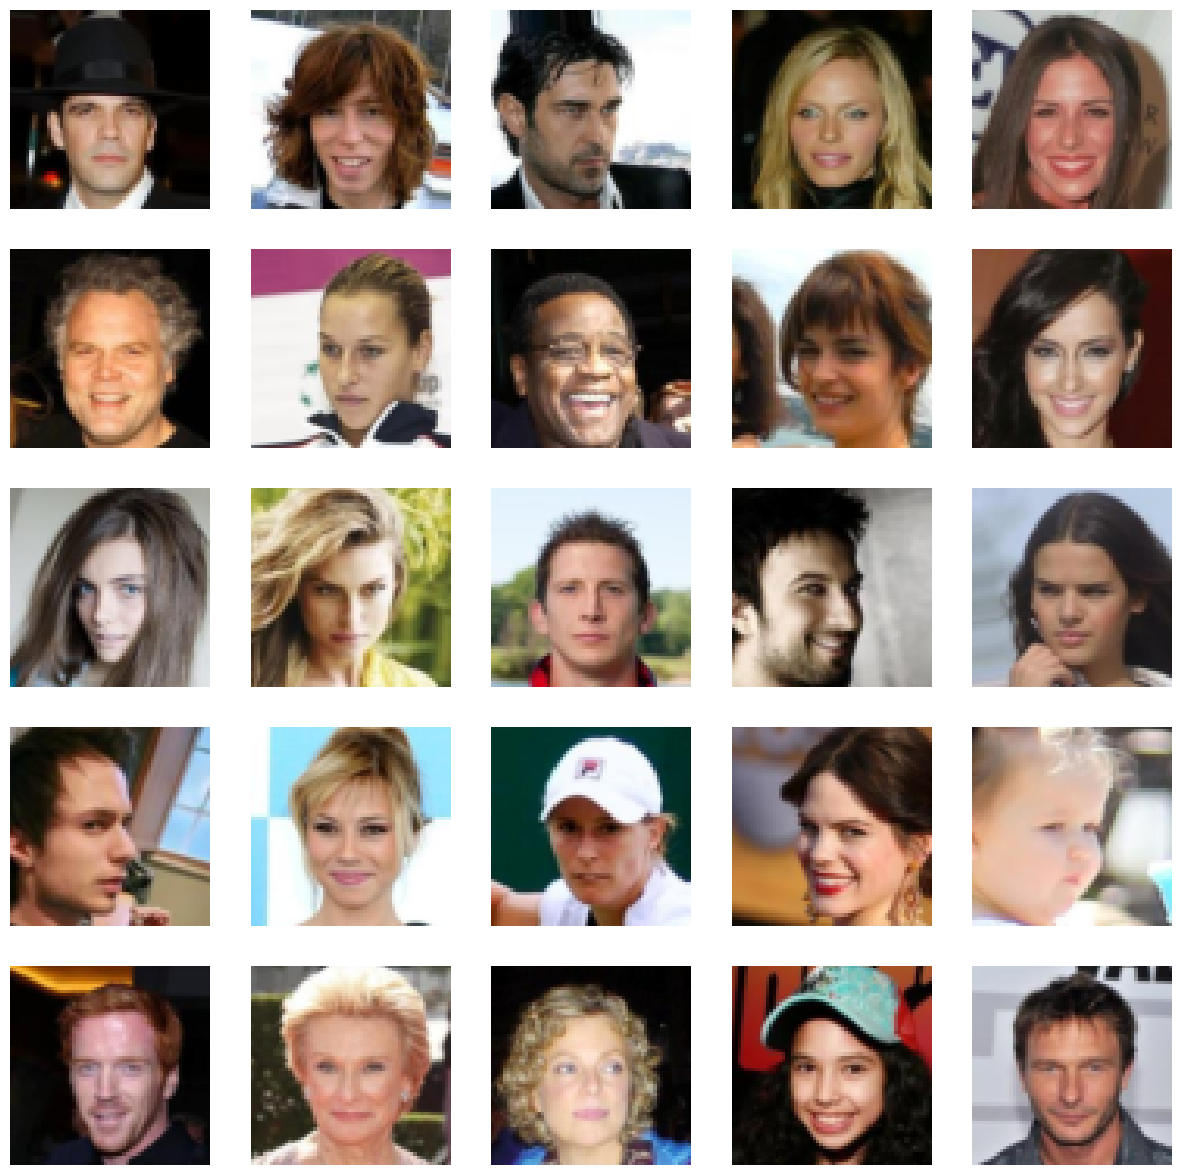

In [5]:
plt.figure(figsize=(15, 15))
for i in range(25):
    random_idx = np.random.randint(len(dataset))
    img = dataset[random_idx]
    plt.subplot(5, 5, i + 1)
    plot_img(img, t_invnormalize)
plt.show()

### Задача 2 (2/10 баллов): Построение и обучение VAE на CelebA

Обучите вариационный автоэнкодер (VAE) до достижения приемлемого качества генерации. Измерьте FID и сохраните результаты для дальнейшего сравнения.

Можно использовать готовые решения из репозитория курса, но предпочтительно написать свою реализацию.

In [8]:
from munch import Munch

vae_args = Munch()

vae_args.batch_size = 1024
vae_args.latent_dim = 100


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvVAE64(nn.Module):
    def __init__(self, args: Munch):
        super().__init__()
        # Encoder
        self.model_args = args
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),  # 64x64 -> 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 32x32 -> 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 16x16 -> 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 8x8 -> 4x4
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(256 * 4 * 4, args.latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, args.latent_dim)
        self.fc_decode = nn.Linear(args.latent_dim, 256 * 4 * 4)
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 4x4 -> 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 8x8 -> 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 16x16 -> 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),  # 32x32 -> 64x64
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(z.size(0), 256, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


Обучение

In [10]:
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=vae_args.batch_size,
    num_workers=4,
    pin_memory=True if device.type == 'cuda' else False,
    shuffle=True
)

In [11]:
import torch.optim as optim

def loss_function(recon_x, x, mean, logvar, beta=1.0):

    batch_size = recon_x.shape[0]

    mse_loss = F.mse_loss(recon_x.view(batch_size, -1), x.view(batch_size, -1), reduction='sum') / batch_size

    kld_loss = -0.5 * torch.sum(1 + logvar - mean.pow(2) - torch.clamp(logvar.exp(), min=1e-8)) / batch_size
    kld_loss *= beta

    return mse_loss + kld_loss


model = ConvVAE64(vae_args).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [ ]:
def train(epoch):
    model.train()
    train_loss = 0
    for batch_idx, data in enumerate(dataloader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        if batch_idx % 100 == 0:
            print(f'Epoch {epoch} [{batch_idx * len(data)}/{len(dataloader.dataset)}] Loss: {loss.item() / len(data):.6f}')
    print(f'====> Epoch {epoch} Average loss: {train_loss / len(dataloader.dataset):.4f}')

# for epoch in range(1, 11):
#     train(epoch)

In [ ]:
# torch.save(model.state_dict(), "./vae64.pth")

In [12]:
model.load_state_dict(torch.load("./vae64.pth"))

<All keys matched successfully>

In [13]:
real_images = torch.stack([dataset[i] for i in range(5)], dim=0)
reconstructions, _, _= model.cpu()(real_images)

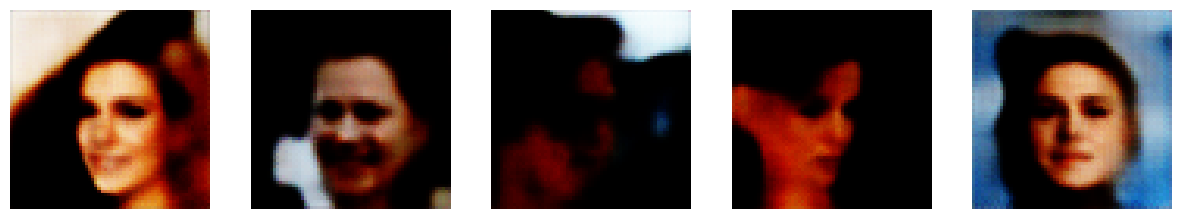

In [14]:
plt.figure(figsize=(15, 15))
for i in range(5):
    img = reconstructions[i].detach().cpu()
    plt.subplot(5, 5, i + 1)
    plot_img(img)
plt.show()

FID

In [ ]:
from utils import FidScore

@torch.no_grad()
def compute_vae_fid(vae: ConvVAE64, num_samples=1000):
    vae.eval()
    real_images = torch.stack([dataset[i] for i in range(num_samples)], dim=0)
    reconstructions, _, _= vae(real_images)
    fid = FidScore()
    fid(real_images, reconstructions)
    return fid.compute()

In [ ]:
fid = compute_vae_fid(model.cpu(), 10000)
fid

// 6500